## NB STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nb=pd.read_csv('../stock_data/nb.csv') ## so it can be small letter. This is cool.
nb=nb.drop(columns=['high_price','low_price'])
nb.rename(columns={'trade_date':'date'},inplace=True)
nb['date']=pd.to_datetime(nb['date'])
nb['month']=nb['date'].dt.month
nb['quarter']=nb['date'].dt.quarter
nb['year']=nb['date'].dt.year

nb

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42791,NB,2017-01-03,142.0,142.0,270366,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43351,NB,2017-01-04,142.0,142.0,1591304,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43461,NB,2017-01-05,142.0,142.0,588049,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43571,NB,2017-01-06,142.0,142.0,1459961,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43661,NB,2017-01-09,142.0,142.0,1667308,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298102,NB,2026-07-13,74.0,74.0,4615237,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298540,NB,2026-07-14,71.0,71.0,729017,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298978,NB,2026-07-15,74.0,74.0,899755,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299416,NB,2026-07-16,74.6,74.6,5536860,2026-07-16T15:10:03.113936+00:00,7,3,2026


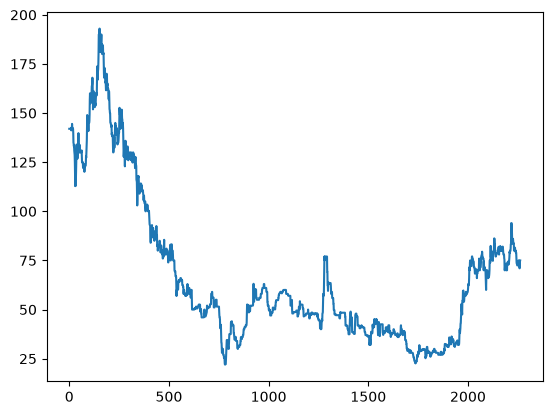

In [2]:
import matplotlib.pyplot as plt

plt.plot(nb['close_price'])
plt.show()

In [3]:
nb_end_month_df = (
    nb
    .sort_values("date")
    .groupby(nb["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nb_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45361,NB,2017-01-31,139.80,139.80,10729060,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47182,NB,2017-02-28,129.20,129.20,3842065,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49298,NB,2017-03-31,127.00,127.00,635177,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51126,NB,2017-04-28,123.01,123.01,2406993,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53048,NB,2017-05-31,149.50,149.50,1432426,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35339,NB,2026-03-31,73.00,73.00,4420519,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281165,NB,2026-04-30,78.70,78.70,11614932,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284231,NB,2026-05-29,83.60,83.60,5566214,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294159,NB,2026-06-30,72.50,72.50,5084072,2026-06-30T15:10:03.08168+00:00,6,2,2026


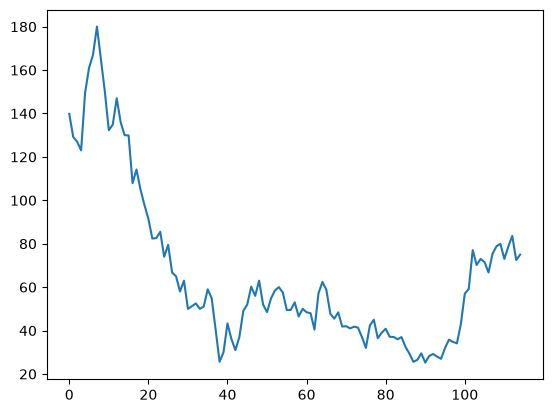

In [4]:
plt.plot(nb_end_month_df['close_price'])
plt.show()

In [5]:
nb_end_month_df['returns']=nb_end_month_df['close_price'].pct_change()*100
nb_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45361,NB,2017-01-31,139.80,139.80,10729060,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47182,NB,2017-02-28,129.20,129.20,3842065,2026-04-08T02:44:45.006295+00:00,2,1,2017,-7.582260
2,49298,NB,2017-03-31,127.00,127.00,635177,2026-04-08T02:45:42.281198+00:00,3,1,2017,-1.702786
3,51126,NB,2017-04-28,123.01,123.01,2406993,2026-04-08T02:51:55.619599+00:00,4,2,2017,-3.141732
4,53048,NB,2017-05-31,149.50,149.50,1432426,2026-04-08T02:52:57.421655+00:00,5,2,2017,21.534835
...,...,...,...,...,...,...,...,...,...,...,...
110,35339,NB,2026-03-31,73.00,73.00,4420519,2026-03-31T15:00:02.085058+00:00,3,1,2026,-8.692933
111,281165,NB,2026-04-30,78.70,78.70,11614932,2026-04-30T15:00:02.170664+00:00,4,2,2026,7.808219
112,284231,NB,2026-05-29,83.60,83.60,5566214,2026-05-29T15:00:02.455558+00:00,5,2,2026,6.226175
113,294159,NB,2026-06-30,72.50,72.50,5084072,2026-06-30T15:10:03.08168+00:00,6,2,2026,-13.277512


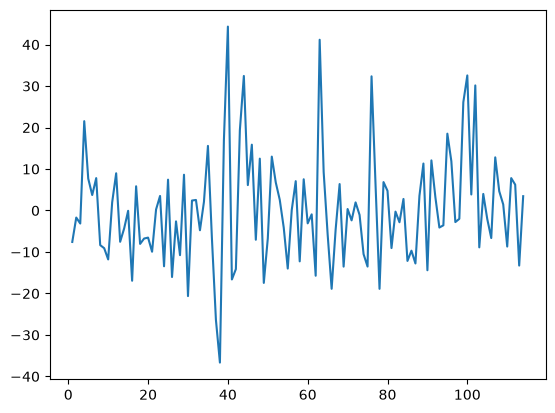

In [6]:
plt.plot(nb_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nb_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-4.702346784334975), np.float64(8.330268729745796e-05), 3, 110, {'1%': np.float64(-3.4912451337340342), '5%': np.float64(-2.8881954545454547), '10%': np.float64(-2.5809876033057852)}, np.float64(811.0016978999396))
stationary


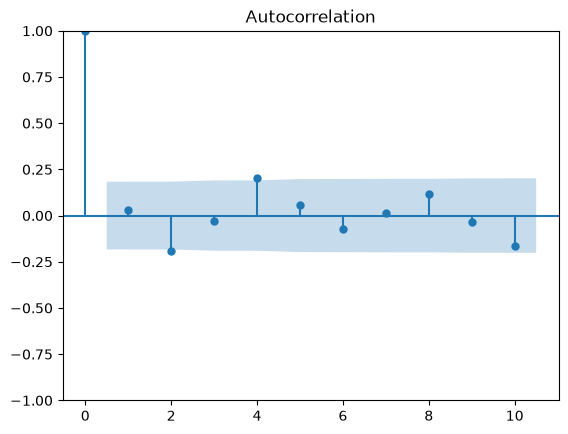

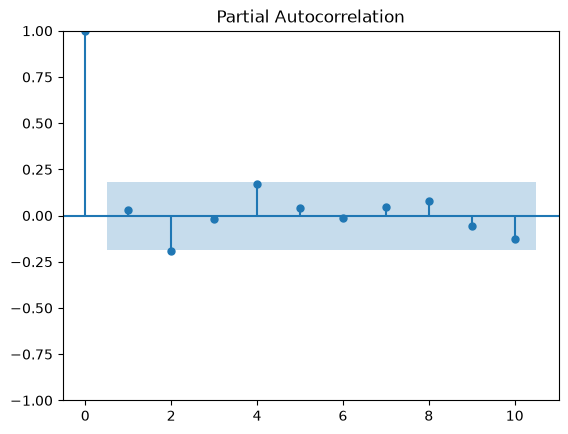

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nb_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nb_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nb_end_month_df['close_price'][:-10]
test=nb_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -265.63799127858226]
[0, 0, 0, 0, 0, 1, -116.43265167227874]
[0, 0, 0, 0, 0, 2, -84.20086305859324]
[0, 0, 0, 0, 1, 0, -59.15112232347517]
[0, 0, 0, 0, 1, 1, -59.609687833260736]
[0, 0, 0, 0, 1, 2, -61.37217303951453]
[0, 0, 0, 0, 2, 0, -73.37533776858487]
[0, 0, 0, 0, 2, 1, -107.55068691579075]
[0, 0, 0, 0, 2, 2, -74.97533625531463]
[0, 0, 0, 1, 0, 0, -64.12268381777112]
[0, 0, 0, 1, 0, 1, -62.003558776734394]
[0, 0, 0, 1, 0, 2, -66.78159433976754]
[0, 0, 0, 1, 1, 0, -59.66513766352417]
[0, 0, 0, 1, 1, 1, -60.45324344750199]
[0, 0, 0, 1, 1, 2, -53.37019671371401]
[0, 0, 0, 1, 2, 0, -71.636457456454]
[0, 0, 0, 1, 2, 1, -71.16443756120681]
[0, 0, 0, 1, 2, 2, -74.15563744785581]
[0, 0, 0, 2, 0, 0, -64.00358010614926]
[0, 0, 0, 2, 0, 1, -63.15180714226868]
[0, 0, 0, 2, 0, 2, -57.89277204894778]
[0, 0, 0, 2, 1, 0, -56.67831482217357]
[0, 0, 0, 2, 1, 1, -59.471894536547424]
[0, 0, 0, 2, 1, 2, -68.1189806417265]
[0, 0, 0, 2, 2, 0, -75.92221827707428]
[0, 0, 0, 2, 2, 1, -73

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-265.637991
708,2,2,2,0,2,0,-263.954453
681,2,2,1,0,2,0,-260.088338
222,0,2,2,0,2,0,-253.382284
465,1,2,2,0,2,0,-252.705108
...,...,...,...,...,...,...,...
342,1,1,0,2,0,0,0.102661
369,1,1,1,2,0,0,0.102999
612,2,1,1,2,0,0,0.103211
585,2,1,0,2,0,0,0.103770


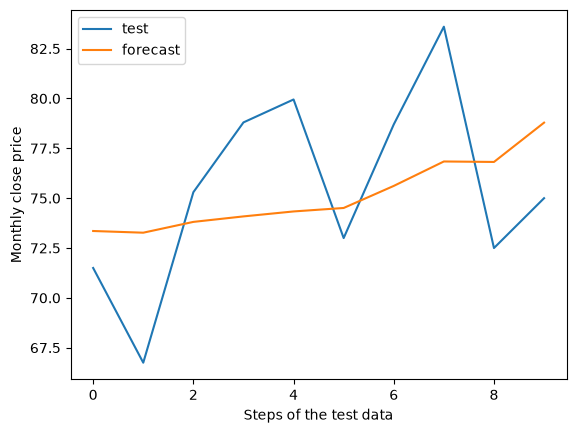

r2_score:  0.10378493358077645
rmse:  4.385968384706937
description:  count    115.000000
mean      65.949913
std       36.921588
min       25.250000
25%       40.675000
50%       53.000000
75%       77.875000
max      180.030000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=nb_end_month_df['close_price'][:-10]
y_test=nb_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,1), 
seasonal_order=(2,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nb_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nb_end_month_df['returns'].dropna()[:-10]
test=nb_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.005506559405303868]
[0, 0, 0, 0, 0, 1, 0.26013213141258673]
[0, 0, 0, 0, 0, 2, 0.26990572233600685]
[0, 0, 0, 0, 1, 0, -2.6822291474817423]
[0, 0, 0, 0, 1, 1, -0.05501016663537084]
[0, 0, 0, 0, 1, 2, -0.267473247545744]
[0, 0, 0, 0, 2, 0, -20.373308193277946]
[0, 0, 0, 0, 2, 1, -3.407914670135421]
[0, 0, 0, 0, 2, 2, -0.8998813487447574]
[0, 0, 0, 1, 0, 0, 0.24897151523685934]
[0, 0, 0, 1, 0, 1, 0.17218076732621523]
[0, 0, 0, 1, 0, 2, -0.00735333979504138]
[0, 0, 0, 1, 1, 0, -0.3854729239729431]
[0, 0, 0, 1, 1, 1, -0.1619366755048055]
[0, 0, 0, 1, 1, 2, -0.028671406244841657]
[0, 0, 0, 1, 2, 0, -8.140010620223313]
[0, 0, 0, 1, 2, 1, -1.0750955385800842]
[0, 0, 0, 1, 2, 2, -1.1201287722665723]
[0, 0, 0, 2, 0, 0, 0.22295340814099096]
[0, 0, 0, 2, 0, 1, 0.06818576061664638]
[0, 0, 0, 2, 0, 2, 0.08357030351708894]
[0, 0, 0, 2, 1, 0, -0.7706483008535867]
[0, 0, 0, 2, 1, 1, -0.200779327215016]
[0, 0, 0, 2, 1, 2, -0.3710171530504338]
[0, 0, 0, 2, 2, 0, -4.752222928115326]

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
177,0,2,0,1,2,0,-813.437555
168,0,2,0,0,2,0,-744.420387
186,0,2,0,2,2,0,-563.367959
413,1,2,0,0,2,2,-379.295044
165,0,2,0,0,1,0,-372.951483
...,...,...,...,...,...,...,...
559,2,0,2,2,0,2,0.458476
539,2,0,2,0,0,0,0.486821
558,2,0,2,2,0,1,0.541605
557,2,0,2,2,0,0,0.586592


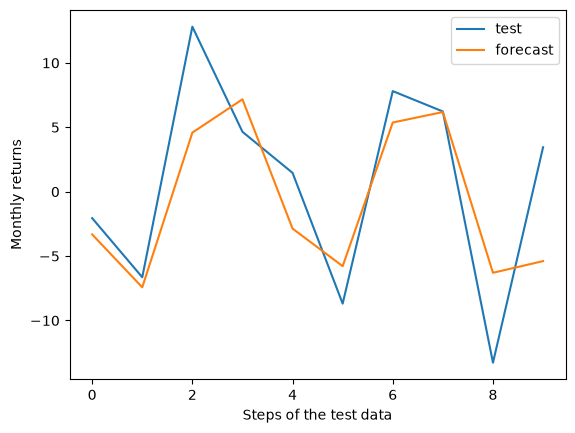

r2_score:  0.6039384240092764
rmse:  4.85999523578145
description:  count    114.000000
mean       0.312307
std       13.387015
min      -36.666667
25%       -8.606852
50%       -0.598986
75%        6.824943
max       44.333333
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=nb_end_month_df['returns'].dropna()[:-10]
y_test=nb_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nb_end_month_df.returns.dropna().describe())

Very good. We will work with this.
